In [ ]:
!pip install pandas numpy==1.23.5 scikit-learn==1.2.2 matplotlib seaborn imbalanced-learn optuna scipy



INFO: pip is looking at multiple versions of imbalanced-learn to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.3/258.3 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 5.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.13.0
    Uninstalling imbalanced

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


#Importing all the relevant packages

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                           precision_score, f1_score, recall_score, roc_auc_score)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import seaborn as sns
import optuna

from scipy.stats import zscore



#Data Exploration and Visualization

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ML Project/healthcare-dataset-stroke-data.csv')

In [ ]:
# Basic dataset information
print("Dataset Info:")
print(df.info())

# Remove unwanted data set
if 'id' in df.columns:
  df.drop(columns=['id'], inplace=True)

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check data types
print("\nData Types:")
print(df.dtypes)

# Check target variable distribution
print("\nStroke Value Counts:")
print(df["stroke"].value_counts())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None

Missing Values:
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married         

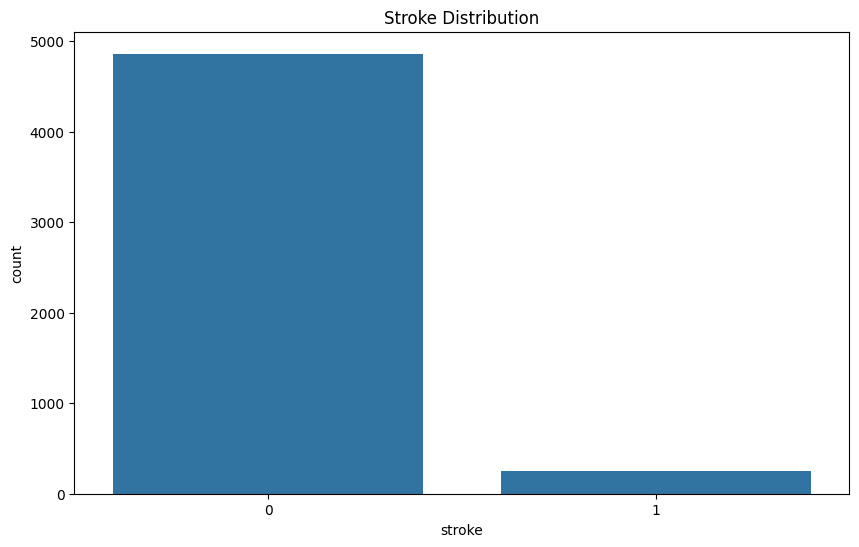

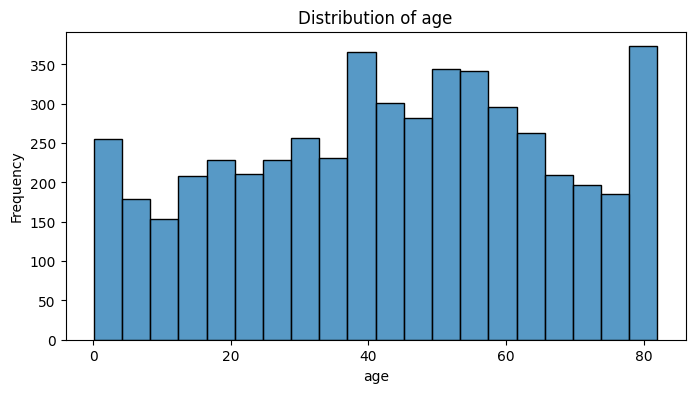

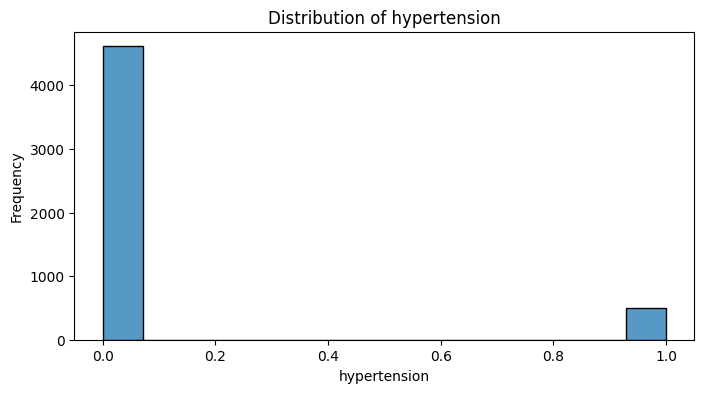

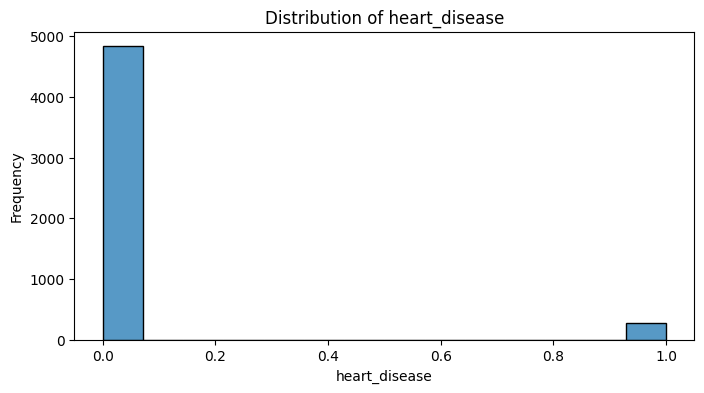

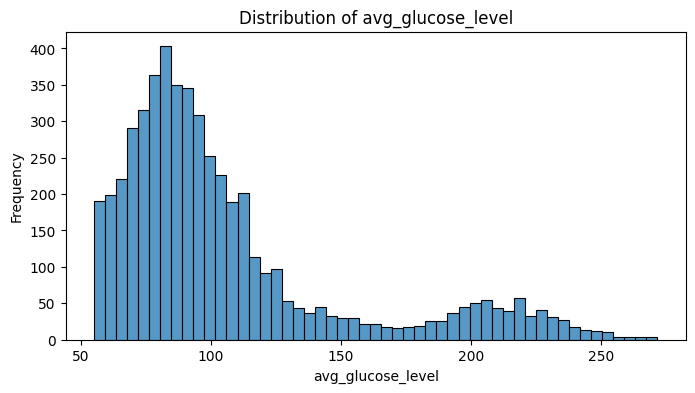

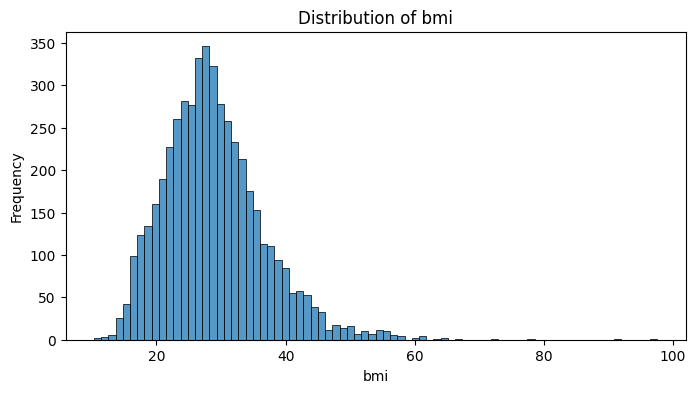

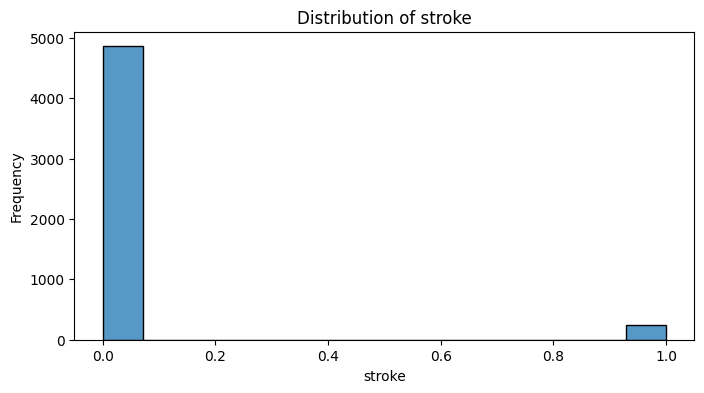

In [ ]:
# Stroke distribution plot
plt.figure(figsize=(10, 6))
sns.countplot(x="stroke", data=df)
plt.title("Stroke Distribution")
plt.show()

# Visualize distributions for all numerical columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col])
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')
    plt.show()

#Data Cleaning and Preprocessing

Missing values in bmi before: 201
Missing values in bmi after: 0


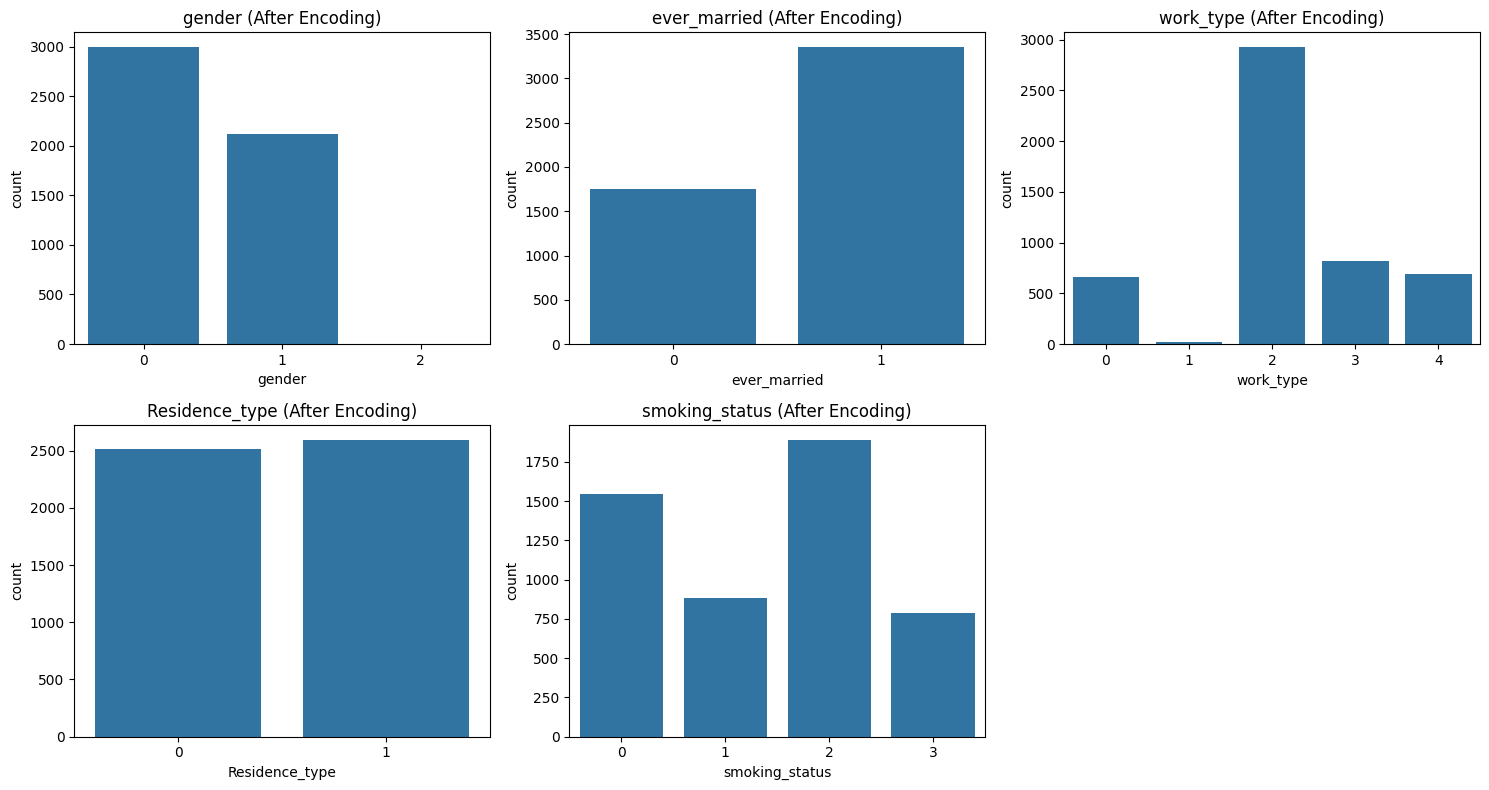


Duplicates before cleaning: 0
Duplicates after cleaning: 0

Original DataFrame shape: (5110, 11)
Cleaned DataFrame shape: (4486, 11)
Number of outliers removed: 624


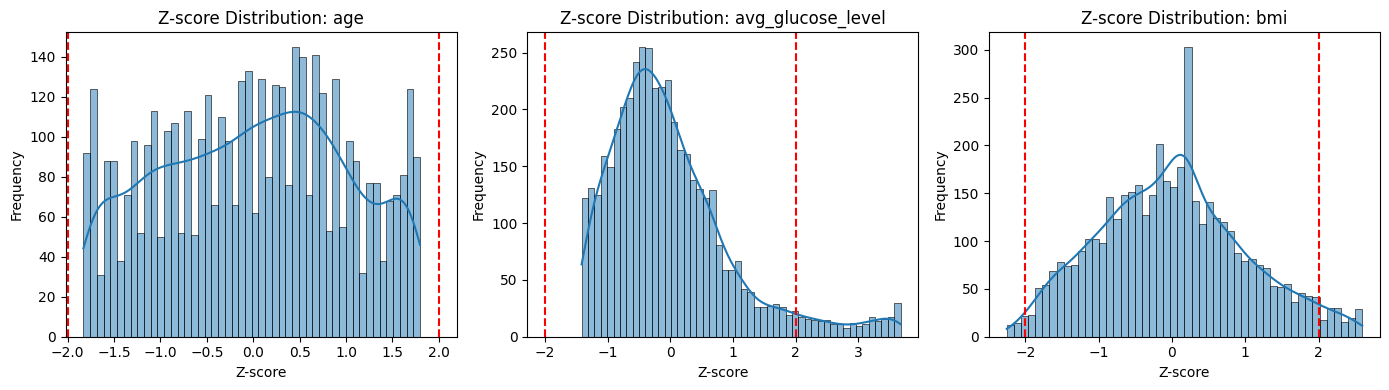

In [ ]:
# Handle missing values
print("Missing values in bmi before:", df['bmi'].isnull().sum())
df['bmi'] = df['bmi'].fillna(df['bmi'].mean())
print("Missing values in bmi after:", df['bmi'].isnull().sum())


# Convert categorical variables to numerical
label_encoder = LabelEncoder()
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])



# Plot count of numerical codes after encoding
plt.figure(figsize=(15, 8))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=df, x=col)
    plt.title(f'{col} (After Encoding)')
plt.tight_layout()
plt.show()


# Handle duplicates
print("\nDuplicates before cleaning:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates after cleaning:", df.duplicated().sum())

# Z-score outlier removal (no prior scaling)
numerical_cols = ['age', 'avg_glucose_level', 'bmi']
print("\nOriginal DataFrame shape:", df.shape)
original_length = len(df)

z_scores = df[numerical_cols].apply(zscore)
df = df[(z_scores < 2).all(axis=1) & (z_scores > -2).all(axis=1)]

print("Cleaned DataFrame shape:", df.shape)
print("Number of outliers removed:", original_length - len(df))

# Recalculate Z-scores (if needed)
numerical_cols = ['age', 'avg_glucose_level', 'bmi']
z_scores = df[numerical_cols].apply(zscore)

# Plot Z-scores for each feature
plt.figure(figsize=(14, 4))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(z_scores[col], bins=50, kde=True)
    plt.axvline(2, color='red', linestyle='--')
    plt.axvline(-2, color='red', linestyle='--')
    plt.title(f'Z-score Distribution: {col}')
    plt.xlabel('Z-score')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


#Inter-feature Correlation

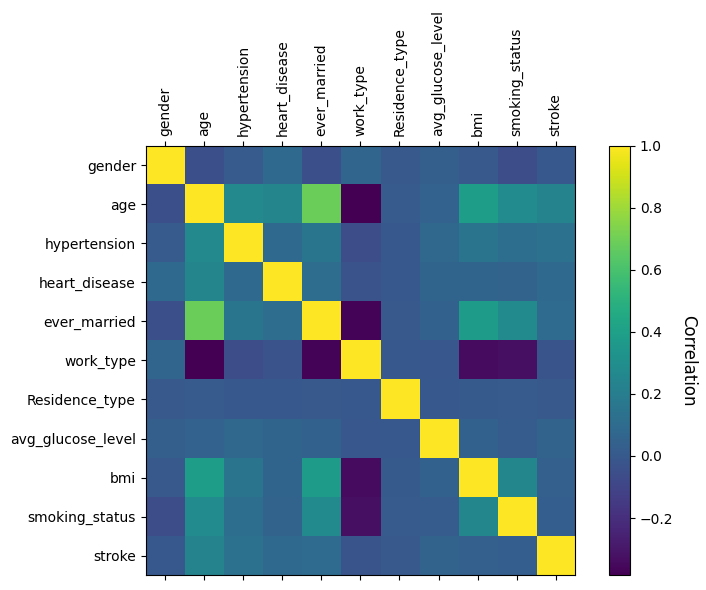

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
im = ax.matshow(df.corr())
ax.set_xticks(np.arange(df.shape[1]))
ax.set_yticks(np.arange(df.shape[1]))
ax.set_xticklabels(df.columns,rotation=90)
ax.set_yticklabels(df.columns)
# Create colorbar
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Correlation", rotation=-90, va="bottom", fontsize=12)
fig.tight_layout()
plt.show()


#Scatter plot

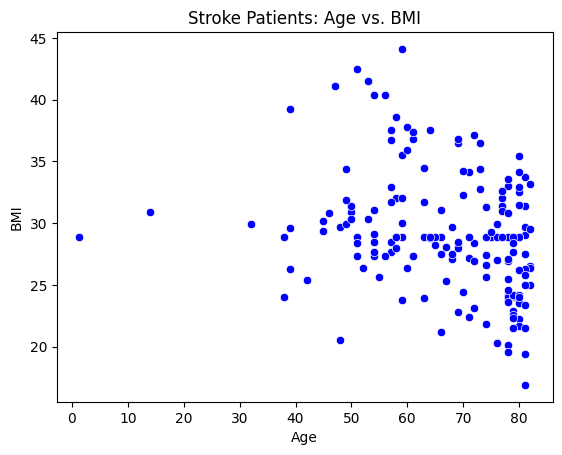

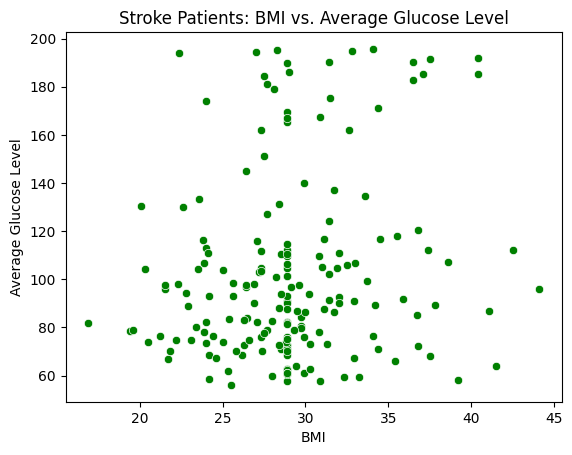

In [ ]:
# Filter stroke patients and drop rows with missing BMI
stroke_df = df[df['stroke'] == 1].dropna(subset=['bmi'])

# Scatter plot
sns.scatterplot(data=stroke_df, x='age', y='bmi', color='blue')
plt.title('Stroke Patients: Age vs. BMI')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.show()
# Filter stroke patients and drop rows with missing BMI
stroke_df = df[df['stroke'] == 1].dropna(subset=['bmi'])

# Scatter plot
sns.scatterplot(data=stroke_df, x='bmi', y='avg_glucose_level', color='green')
plt.title('Stroke Patients: BMI vs. Average Glucose Level')
plt.xlabel('BMI')
plt.ylabel('Average Glucose Level')
plt.show()


#Class (Target) Distribution
Now, let's take a look at the distribution of class (target). If the class is highly imbalanced, we have to solve this issue so that our model will not be biased towards the majority class.

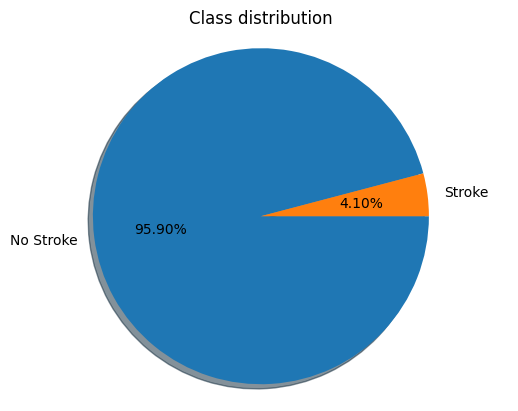

# samples associated with no stroke: 4302
# samples associated with stroke: 184


In [ ]:
class_occur = df['stroke'].value_counts()
class_names = ['No Stroke','Stroke']
fig, ax = plt.subplots()
ax.pie(class_occur, labels=class_names, autopct='%1.2f%%',
        shadow=True, startangle=0, counterclock=False)
ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
ax.set_title('Class distribution')
plt.show()
print("# samples associated with no stroke: {}".format(class_occur[0]))
print("# samples associated with stroke: {}".format(class_occur[1]))

#Handle Imbalanced Class (SMOTE)

Class distribution before SMOTE:
Train: Counter({0: 2752, 1: 118})
Validation: Counter({0: 689, 1: 29})
Test: Counter({0: 861, 1: 37})

After SMOTE (Training Set Only):
Resampled Train Class Distribution: Counter({0: 2752, 1: 2752})


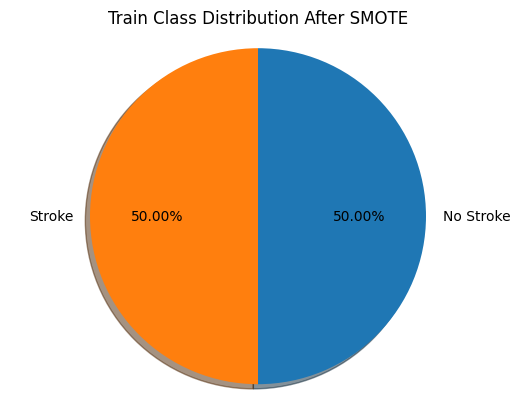

In [ ]:
from collections import Counter
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# Step 1: Split the dataset into features and target variable
X = df.drop(columns=['stroke'])
y = df['stroke']

# First split: Train+Validation (80%) and Test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Second split: Train (80% of 80%) and Validation (20% of 80%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=42
)

print("Class distribution before SMOTE:")
print("Train:", Counter(y_train))
print("Validation:", Counter(y_val))
print("Test:", Counter(y_test))

# Step 2: Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE (Training Set Only):")
print("Resampled Train Class Distribution:", Counter(y_train_resampled))

# Plot class distribution AFTER SMOTE
class_names = ['No Stroke', 'Stroke']
class_occur_after = Counter(y_train_resampled)

fig, ax = plt.subplots()
ax.pie(class_occur_after.values(), labels=class_names, autopct='%1.2f%%',
       shadow=True, startangle=90, counterclock=False)
ax.axis('equal')
ax.set_title('Train Class Distribution After SMOTE')
plt.show()


#PCA

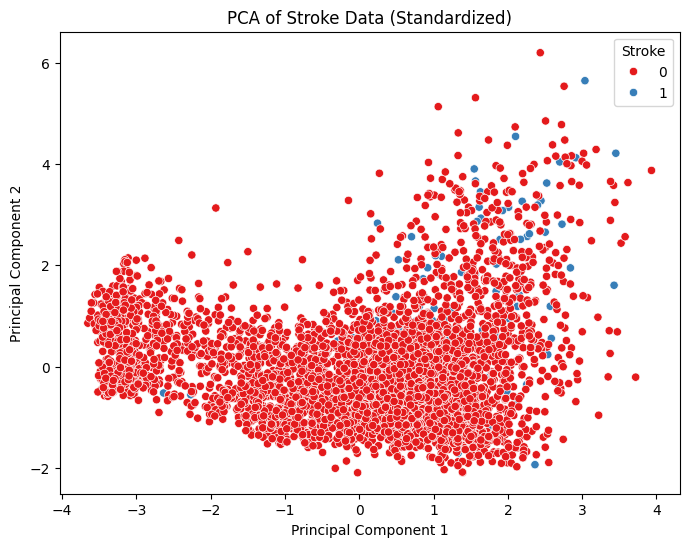

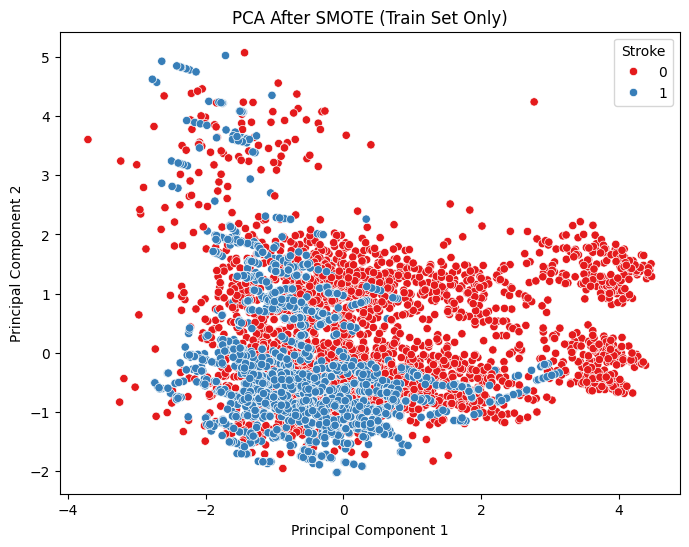

In [ ]:
# Separate features and target
X = df.drop(columns=['stroke'])
y = df['stroke']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

# Build PCA DataFrame
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['stroke'] = y.values

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='stroke', data=pca_df, palette='Set1')
plt.title("PCA of Stroke Data (Standardized)")
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Stroke', loc='upper right')
plt.show()

# Step 3: Standardize resampled features
scaler = StandardScaler()
X_resampled_scaled = scaler.fit_transform(X_train_resampled)

# Step 4: Apply PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_resampled_scaled)

# Step 5: Create PCA DataFrame
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['stroke'] = y_train_resampled.values

# Step 6: Plot PCA
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='stroke', data=pca_df, palette='Set1')
plt.title("PCA After SMOTE (Train Set Only)")
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Stroke', loc='upper right')


#🔷 LDA (Linear Discriminant Analysis)


Reduce dimensionality (similar to PCA but with class labels).

Maximize class separability by projecting data to a lower-dimensional space where classes are more distinct.

To transform high-dimensional feature data into a single LDA component (LD1) that captures the most separable direction between the two classes:

stroke = 0 (no stroke)

stroke = 1 (stroke)

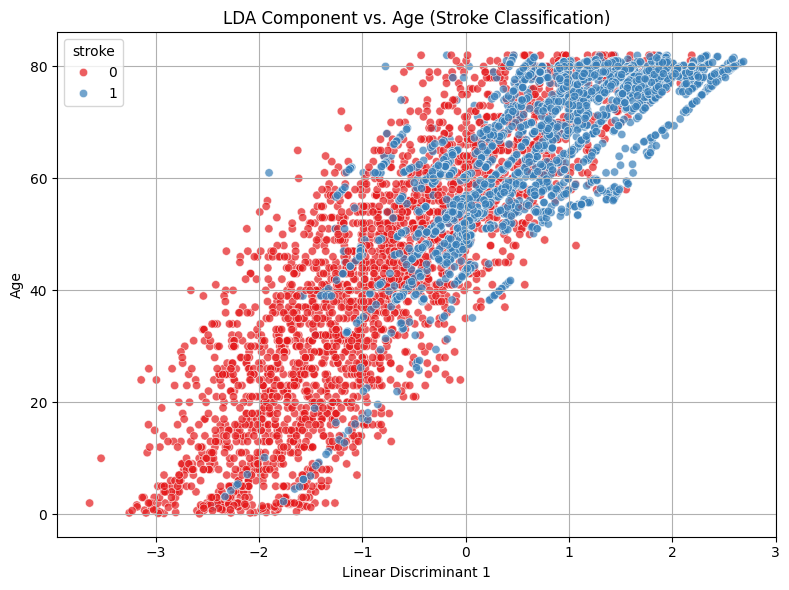

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Apply LDA (1 component for binary classification)
lda = LDA(n_components=1)
X_lda_1D = lda.fit_transform(X_resampled_scaled, y_train_resampled)

# Build DataFrame with LDA component and corresponding age
lda_df = pd.DataFrame({
    'LD1': X_lda_1D.flatten(),
    'age': X_train_resampled['age'].values,  # Use original age values
    'stroke': y_train_resampled.values
})

# Scatter plot: LDA vs Age
plt.figure(figsize=(8, 6))
sns.scatterplot(data=lda_df, x='LD1', y='age', hue='stroke', palette='Set1', alpha=0.7)
plt.title("LDA Component vs. Age (Stroke Classification)")
plt.xlabel("Linear Discriminant 1")
plt.ylabel("Age")
plt.grid(True)
plt.tight_layout()
plt.show()


#🔷 t-SNE (t-distributed Stochastic Neighbor Embedding)

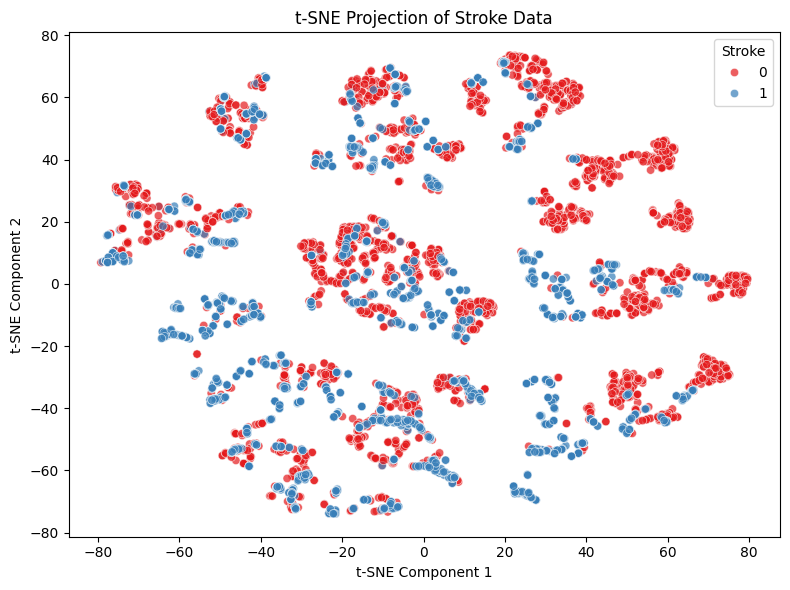

In [ ]:
from sklearn.manifold import TSNE

# Apply t-SNE (2D)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_resampled_scaled)

# Create DataFrame and plot
tsne_df = pd.DataFrame(data=X_tsne, columns=['TSNE1', 'TSNE2'])
tsne_df['stroke'] = y_train_resampled.values

plt.figure(figsize=(8, 6))
sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='stroke', palette='Set1', alpha=0.7)
plt.title("t-SNE Projection of Stroke Data")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title='Stroke')
plt.tight_layout()
plt.show()


# Model Training and Evaluation
This block of code is responsible for training, evaluating, and visualizing the performance of multiple classification models for stroke prediction.

#Naive Bayes

[I 2025-05-14 19:52:48,192] A new study created in memory with name: no-name-2f073c62-69e6-4121-b9b2-d2c21dc2fdd5
[I 2025-05-14 19:52:48,496] Trial 0 finished with value: 0.7138084632516704 and parameters: {'k': 5, 'method': 'mutual'}. Best is trial 0 with value: 0.7138084632516704.
[I 2025-05-14 19:52:48,773] Trial 1 finished with value: 0.7182628062360802 and parameters: {'k': 5, 'method': 'mutual'}. Best is trial 1 with value: 0.7182628062360802.
[I 2025-05-14 19:52:48,812] Trial 2 finished with value: 0.6993318485523385 and parameters: {'k': 6, 'method': 'kbest'}. Best is trial 1 with value: 0.7182628062360802.
[I 2025-05-14 19:52:49,091] Trial 3 finished with value: 0.7138084632516704 and parameters: {'k': 6, 'method': 'mutual'}. Best is trial 1 with value: 0.7182628062360802.
[I 2025-05-14 19:52:49,130] Trial 4 finished with value: 0.7071269487750557 and parameters: {'k': 8, 'method': 'kbest'}. Best is trial 1 with value: 0.7182628062360802.
[I 2025-05-14 19:52:49,423] Trial 5 fi

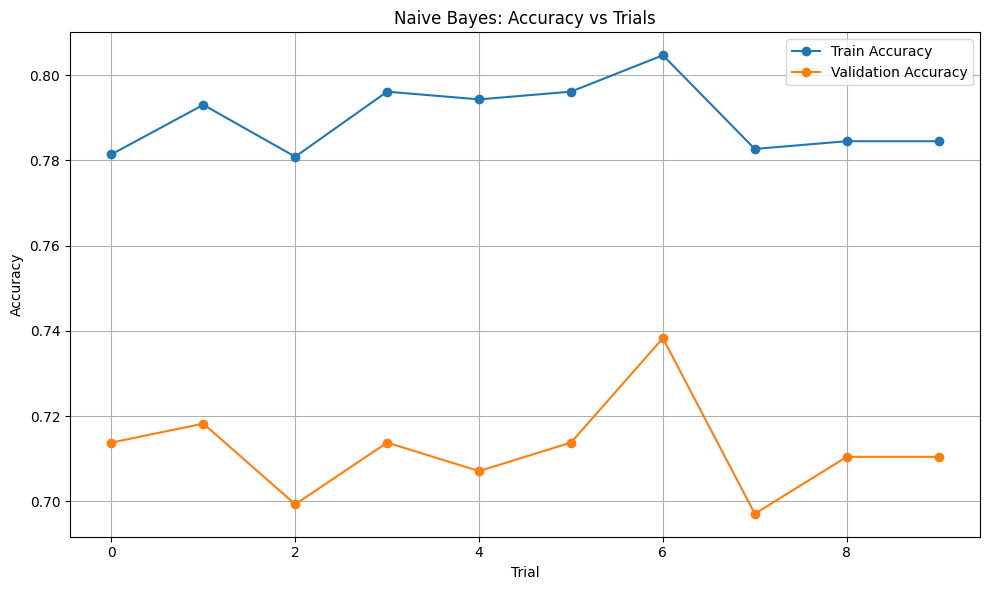


Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.95      0.96       861
           1       0.14      0.19      0.16        37

    accuracy                           0.92       898
   macro avg       0.55      0.57      0.56       898
weighted avg       0.93      0.92      0.92       898

Accuracy: 0.919
Precision: 0.552
Recall: 0.570
F1: 0.559
Roc_auc: 0.745


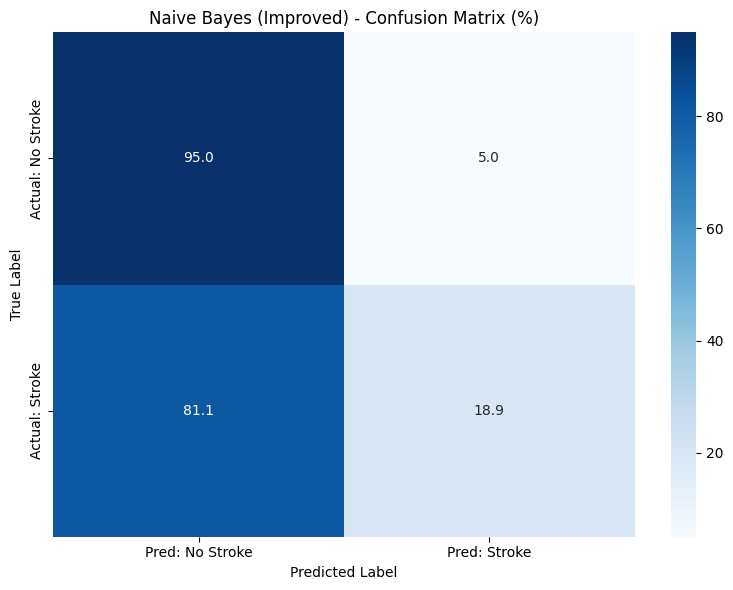

In [ ]:

from sklearn.naive_bayes import GaussianNB
from sklearn.feature_selection import SelectKBest, mutual_info_classif, f_classif
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from imblearn.combine import SMOTETomek
from sklearn.calibration import CalibratedClassifierCV
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import optuna
import numpy as np

# === Step 2: Feature selection ===
def select_features(X_train, y_train, X_test, method='mutual', k=10):
    score_func = mutual_info_classif if method == 'mutual' else f_classif
    selector = SelectKBest(score_func=score_func, k=k)
    return selector.fit_transform(X_train, y_train), selector.transform(X_test), selector

# === Step 3: Optuna optimization ===
train_accuracies_nb, val_accuracies_nb = [], []

def optimize_nb(trial):
    k = trial.suggest_int('k', 5, min(20, X_train_resampled.shape[1]))
    method = trial.suggest_categorical('method', ['kbest', 'mutual'])
    X_train_sel, X_test_sel, _ = select_features(X_train_resampled, y_train_resampled, X_test, method=method, k=k)

    model = GaussianNB()
    train_acc = cross_val_score(model, X_train_sel, y_train_resampled, cv=5, scoring='accuracy').mean()
    model.fit(X_train_sel, y_train_resampled)
    val_acc = accuracy_score(y_test, model.predict(X_test_sel))

    train_accuracies_nb.append(train_acc)
    val_accuracies_nb.append(val_acc)
    return val_acc

study = optuna.create_study(direction='maximize')
study.optimize(optimize_nb, n_trials=10)

# === Plot Accuracy ===
plt.figure(figsize=(10, 6))
plt.plot(train_accuracies_nb, label="Train Accuracy", marker='o')
plt.plot(val_accuracies_nb, label="Validation Accuracy", marker='o')
plt.title("Naive Bayes: Accuracy vs Trials")
plt.xlabel("Trial")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# === Step 4: Best features and GridSearch ===
best_k = study.best_params['k']
best_method = study.best_params['method']
X_train_nb, X_test_nb, _ = select_features(X_train_resampled, y_train_resampled, X_test, method=best_method, k=best_k)

grid = GridSearchCV(
    GaussianNB(),
    param_grid={'priors': [[0.8, 0.2], [0.9, 0.1], None]},
    scoring='f1',
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    n_jobs=-1
)
grid.fit(X_train_nb, y_train_resampled)
best_model = CalibratedClassifierCV(grid.best_estimator_, cv=3)
best_model.fit(X_train_nb, y_train_resampled)

# === Step 5: Threshold tuning ===
y_probs = best_model.predict_proba(X_test_nb)[:, 1]
prec, rec, thresholds = precision_recall_curve(y_test, y_probs)
f1_scores = 2 * (prec * rec) / (prec + rec + 1e-9)
best_threshold = thresholds[np.argmax(f1_scores)]

# === Final prediction and evaluation ===
y_pred = (y_probs >= best_threshold).astype(int)

# Initialize results dictionary only if it doesn't exist
global_results = globals().get('results', None)
if global_results is None:
    results = {}
else:
    results = global_results

results['Naive Bayes'] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, average='macro'),
    'recall': recall_score(y_test, y_pred, average='macro'),
    'f1': f1_score(y_test, y_pred, average='macro'),
    'roc_auc': roc_auc_score(y_test, y_probs)
}

# Print classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))
for m, v in results['Naive Bayes'].items():
    print(f"{m.capitalize()}: {v:.3f}")

# === Confusion Matrix ===
cm = confusion_matrix(y_test, y_pred)
cm_percent = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(8, 6))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=['Pred: No Stroke', 'Pred: Stroke'],
            yticklabels=['Actual: No Stroke', 'Actual: Stroke'])
plt.title('Naive Bayes (Improved) - Confusion Matrix (%)')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

#svm


[I 2025-05-14 19:52:53,655] A new study created in memory with name: no-name-e8ba9806-ecd0-44aa-a875-f2ab6cda85ee
[I 2025-05-14 19:53:06,065] Trial 0 finished with value: 0.7238307349665924 and parameters: {'k': 5, 'C': 1.7870458619200176, 'method': 'mutual'}. Best is trial 0 with value: 0.7238307349665924.
[I 2025-05-14 19:53:14,676] Trial 1 finished with value: 0.7683741648106904 and parameters: {'k': 8, 'C': 0.14390819909631994, 'method': 'kbest'}. Best is trial 1 with value: 0.7683741648106904.
[I 2025-05-14 19:53:26,585] Trial 2 finished with value: 0.7683741648106904 and parameters: {'k': 8, 'C': 0.4965343356031368, 'method': 'mutual'}. Best is trial 1 with value: 0.7683741648106904.
[I 2025-05-14 19:53:37,061] Trial 3 finished with value: 0.7405345211581291 and parameters: {'k': 5, 'C': 2.296714768833163, 'method': 'kbest'}. Best is trial 1 with value: 0.7683741648106904.
[I 2025-05-14 19:53:51,571] Trial 4 finished with value: 0.7616926503340757 and parameters: {'k': 9, 'C': 1.

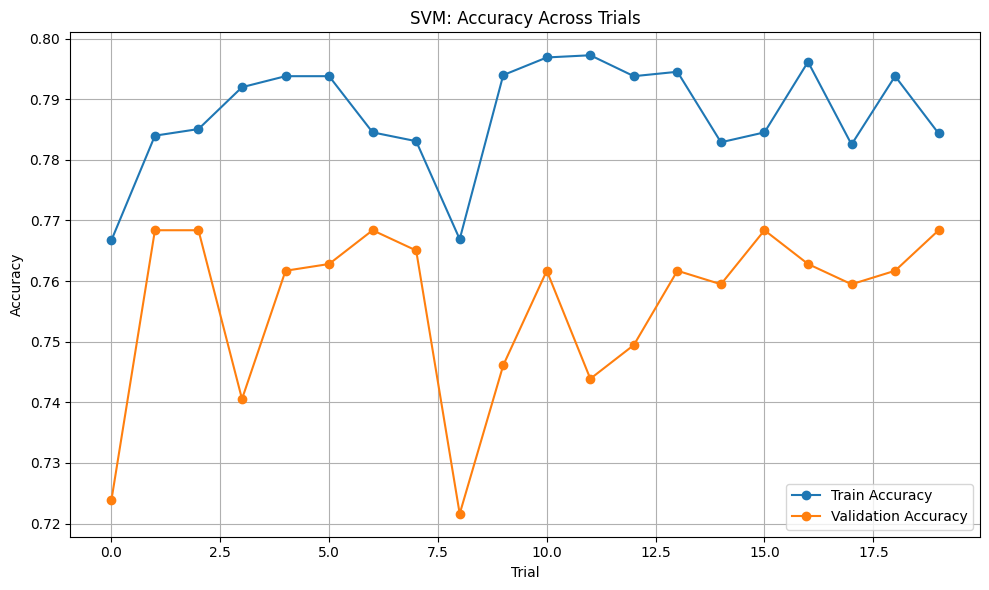

Fitting 2 folds for each of 1 candidates, totalling 2 fits

✅ GridSearchCV Best Params: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best F1 Score from GridSearchCV: 0.784

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.78      0.87       861
           1       0.11      0.62      0.18        37

    accuracy                           0.77       898
   macro avg       0.54      0.70      0.53       898
weighted avg       0.94      0.77      0.84       898

Accuracy: 0.772
Precision: 0.544
Recall: 0.700
F1: 0.525
Roc_auc: 0.768


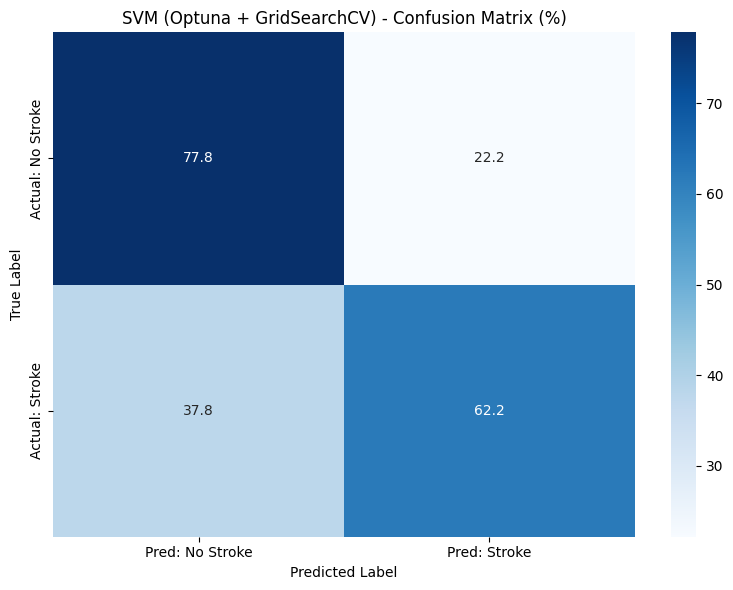

In [ ]:

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif, f_classif
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import numpy as np

# === Step 1: Feature selection ===
def select_features(X_train, y_train, X_test, method='mutual', k=10):
    score_func = mutual_info_classif if method == 'mutual' else f_classif
    selector = SelectKBest(score_func=score_func, k=k)
    return selector.fit_transform(X_train, y_train), selector.transform(X_test), selector

# === Step 2: Optuna optimization ===
train_accuracies_svm, val_accuracies_svm = [], []

def optimize_svm(trial):
    k = trial.suggest_int('k', 5, min(15, X_train_resampled.shape[1]))
    C = trial.suggest_float('C', 0.1, 10, log=True)
    method = trial.suggest_categorical('method', ['kbest', 'mutual'])

    X_train_sel, X_test_sel, _ = select_features(X_train_resampled, y_train_resampled, X_test, method=method, k=k)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_sel)
    X_test_scaled = scaler.transform(X_test_sel)

    model = SVC(C=C, kernel='linear', probability=True)
    train_acc = cross_val_score(model, X_train_scaled, y_train_resampled, cv=3, scoring='accuracy', n_jobs=-1).mean()
    model.fit(X_train_scaled, y_train_resampled)
    val_acc = accuracy_score(y_test, model.predict(X_test_scaled))

    train_accuracies_svm.append(train_acc)
    val_accuracies_svm.append(val_acc)
    return val_acc

study = optuna.create_study(direction='maximize')
study.optimize(optimize_svm, n_trials=20)

# === Step 3: Visualize Accuracy ===
plt.figure(figsize=(10, 6))
plt.plot(train_accuracies_svm, label="Train Accuracy", marker='o')
plt.plot(val_accuracies_svm, label="Validation Accuracy", marker='o')
plt.title("SVM: Accuracy Across Trials")
plt.xlabel("Trial")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# === Step 4: Extract best parameters
best_k = study.best_params['k']
best_method = study.best_params['method']
best_C = study.best_params['C']

X_train_svm, X_test_svm, _ = select_features(X_train_resampled, y_train_resampled, X_test, method=best_method, k=best_k)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_svm)
X_test_scaled = scaler.transform(X_test_svm)

# === Step 5: GridSearchCV (simple, fast)
param_grid = {
    'C': [1],
    'kernel': ['linear'],
    'gamma': ['scale']
}
grid_search = GridSearchCV(
    estimator=SVC(probability=True),
    param_grid=param_grid,
    cv=2,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_scaled, y_train_resampled)
svm_model = grid_search.best_estimator_

print("\n✅ GridSearchCV Best Params:", grid_search.best_params_)
print(f"Best F1 Score from GridSearchCV: {grid_search.best_score_:.3f}")

# === Step 6: Predict and Evaluate ===
svm_model.fit(X_train_scaled, y_train_resampled)
y_prob = svm_model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)  # default threshold

# Add SVM results to the same results dictionary
results['SVM'] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, average='macro'),
    'recall': recall_score(y_test, y_pred, average='macro'),
    'f1': f1_score(y_test, y_pred, average='macro'),
    'roc_auc': roc_auc_score(y_test, y_prob)
}

# Print results
print("\nClassification Report:\n", classification_report(y_test, y_pred))
for m, v in results['SVM'].items():
    print(f"{m.capitalize()}: {v:.3f}")

# === Confusion Matrix Plot ===
cm = confusion_matrix(y_test, y_pred)
cm_percent = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(8, 6))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=['Pred: No Stroke', 'Pred: Stroke'],
            yticklabels=['Actual: No Stroke', 'Actual: Stroke'])
plt.title('SVM (Optuna + GridSearchCV) - Confusion Matrix (%)')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


#KNN

[I 2025-05-14 19:57:11,466] A new study created in memory with name: no-name-186a2a8a-db16-484f-a2d9-a85e9e8849b5
[I 2025-05-14 19:57:11,535] Trial 0 finished with value: 0.4859759587864911 and parameters: {'k': 3, 'method': 'kbest', 'weights': 'distance', 'p': 2, 'metric': 'manhattan'}. Best is trial 0 with value: 0.4859759587864911.
[I 2025-05-14 19:57:11,662] Trial 1 finished with value: 0.5322260172491773 and parameters: {'k': 8, 'method': 'kbest', 'weights': 'distance', 'p': 1, 'metric': 'manhattan'}. Best is trial 1 with value: 0.5322260172491773.
[I 2025-05-14 19:57:12,312] Trial 2 finished with value: 0.5384642650377496 and parameters: {'k': 10, 'method': 'mutual', 'weights': 'uniform', 'p': 1, 'metric': 'chebyshev'}. Best is trial 2 with value: 0.5384642650377496.
[I 2025-05-14 19:57:12,664] Trial 3 finished with value: 0.5465316779978323 and parameters: {'k': 7, 'method': 'mutual', 'weights': 'distance', 'p': 2, 'metric': 'chebyshev'}. Best is trial 3 with value: 0.5465316779

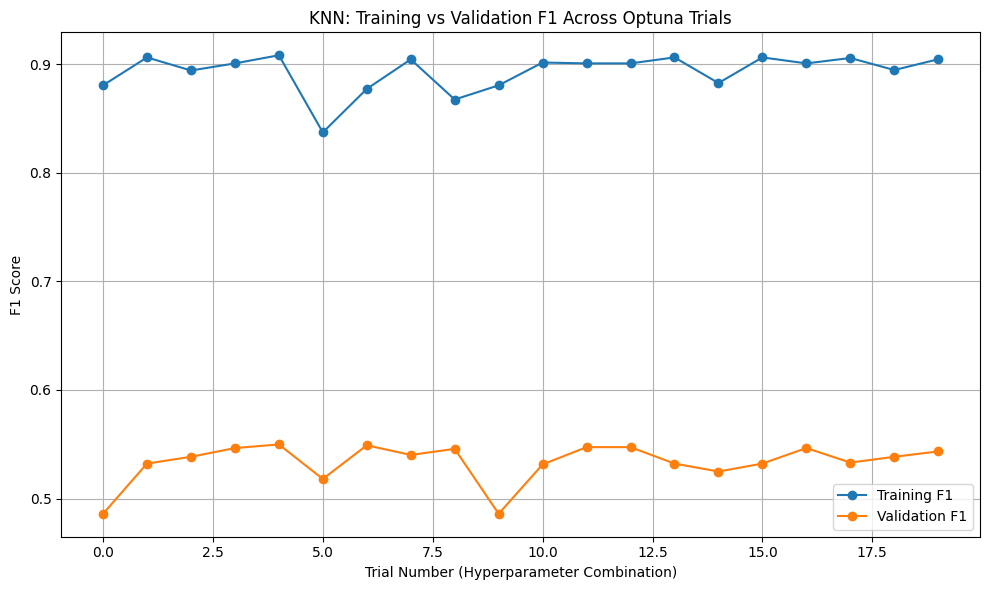


✅ GridSearchCV Best Parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
Best F1 Score from GridSearchCV: 0.913
Best threshold for F1: 0.225

Classification Report (Threshold Tuned):
               precision    recall  f1-score   support

           0       0.98      0.78      0.87       861
           1       0.11      0.62      0.18        37

    accuracy                           0.77       898
   macro avg       0.54      0.70      0.53       898
weighted avg       0.94      0.77      0.84       898

Accuracy: 0.773
Precision: 0.544
Recall: 0.700
F1: 0.526
Roc_auc: 0.694


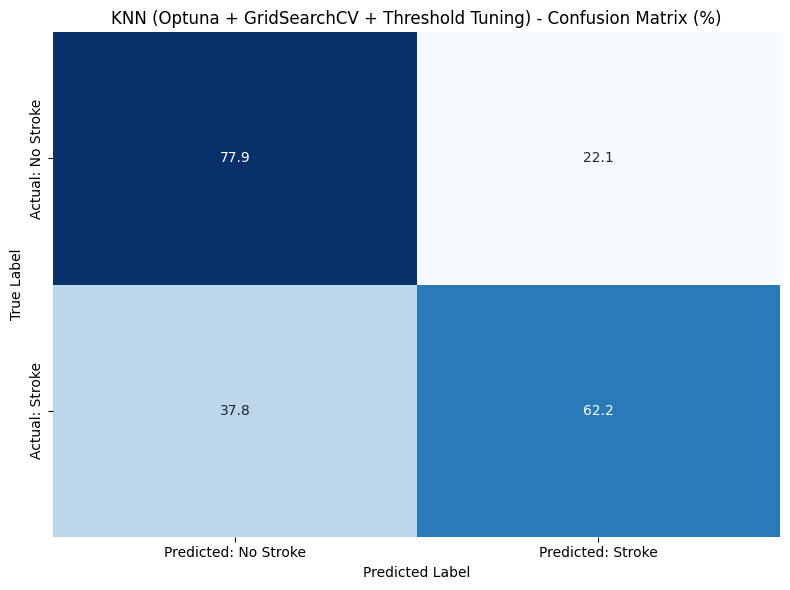

In [ ]:
from sklearn.metrics import precision_recall_curve


# === Step 1: Feature selection function ===
def select_features(X_train, y_train, X_test, method='mutual', k=10):
    selector = SelectKBest(score_func=mutual_info_classif if method == 'mutual' else f_classif, k=k)
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)
    return X_train_selected, X_test_selected, selector

# === Step 2: Optuna Optimization + Accuracy Recording ===
train_accuracies_knn = []
val_accuracies_knn = []

from sklearn.metrics import f1_score

def optimize_knn(trial):
    k = trial.suggest_int('k', 3, min(20, X_train_resampled.shape[1]))
    method = trial.suggest_categorical('method', ['kbest', 'mutual'])
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    p = trial.suggest_int('p', 1, 2)
    metric = trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'chebyshev'])

    X_train_sel, X_test_sel, _ = select_features(X_train_resampled, y_train_resampled, X_test, method=method, k=k)

    model = KNeighborsClassifier(n_neighbors=5, weights=weights, p=p, metric=metric)
    train_f1 = cross_val_score(model, X_train_sel, y_train_resampled, cv=5, scoring='f1').mean()
    model.fit(X_train_sel, y_train_resampled)
    val_f1 = f1_score(y_test, model.predict(X_test_sel), average='macro')

    train_accuracies_knn.append(train_f1)
    val_accuracies_knn.append(val_f1)

    return val_f1

study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(optimize_knn, n_trials=20)

# === Plot F1 vs Trials ===
plt.figure(figsize=(10, 6))
plt.plot(range(len(train_accuracies_knn)), train_accuracies_knn, label="Training F1", marker='o')
plt.plot(range(len(val_accuracies_knn)), val_accuracies_knn, label="Validation F1", marker='o')
plt.xlabel("Trial Number (Hyperparameter Combination)")
plt.ylabel("F1 Score")
plt.title("KNN: Training vs Validation F1 Across Optuna Trials")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Step 3: GridSearchCV to tune KNN ===
best_k = study_knn.best_params['k']
best_method = study_knn.best_params['method']
best_weights = study_knn.best_params['weights']
best_p = study_knn.best_params['p']
best_metric = study_knn.best_params['metric']
X_train_knn, X_test_knn, selector_knn = select_features(X_train_resampled, y_train_resampled, X_test, method=best_method, k=best_k)

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2],
    'metric': ['euclidean', 'manhattan', 'chebyshev']
}

grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)
grid_knn.fit(X_train_knn, y_train_resampled)
best_model = grid_knn.best_estimator_

print("\n✅ GridSearchCV Best Parameters:", grid_knn.best_params_)
print(f"Best F1 Score from GridSearchCV: {grid_knn.best_score_:.3f}")

# === Step 4: Train and Evaluate ===
best_model.fit(X_train_knn, y_train_resampled)
y_prob = best_model.predict_proba(X_test_knn)[:, 1]

# === Step 5: Threshold Tuning ===
prec, rec, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (prec * rec) / (prec + rec + 1e-9)
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best threshold for F1: {best_threshold:.3f}")
y_pred = (y_prob >= best_threshold).astype(int)

# === Step 6: Metrics ===
print("\nClassification Report (Threshold Tuned):\n", classification_report(y_test, y_pred))

results['KNN'] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, average='macro'),
    'recall': recall_score(y_test, y_pred, average='macro'),
    'f1': f1_score(y_test, y_pred, average='macro'),
    'roc_auc': roc_auc_score(y_test, y_prob)
}

for m, v in results['KNN'].items():
    print(f"{m.capitalize()}: {v:.3f}")

# === Step 7: Confusion Matrix ===
cm = confusion_matrix(y_test, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(8, 6))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap="Blues", cbar=False,
            xticklabels=['Predicted: No Stroke', 'Predicted: Stroke'],
            yticklabels=['Actual: No Stroke', 'Actual: Stroke'])

plt.title('KNN (Optuna + GridSearchCV + Threshold Tuning) - Confusion Matrix (%)')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


#Decision Tree

[I 2025-05-14 19:57:37,862] A new study created in memory with name: no-name-16913acb-2713-4810-a6ec-c43b2dfcb197
[I 2025-05-14 19:57:38,434] Trial 0 finished with value: 0.7884187082405345 and parameters: {'k': 5, 'max_depth': 9, 'method': 'mutual'}. Best is trial 0 with value: 0.7884187082405345.
[I 2025-05-14 19:57:38,984] Trial 1 finished with value: 0.8541202672605791 and parameters: {'k': 5, 'max_depth': 15, 'method': 'mutual'}. Best is trial 1 with value: 0.8541202672605791.
[I 2025-05-14 19:57:39,193] Trial 2 finished with value: 0.878619153674833 and parameters: {'k': 8, 'max_depth': 15, 'method': 'kbest'}. Best is trial 2 with value: 0.878619153674833.
[I 2025-05-14 19:57:39,318] Trial 3 finished with value: 0.7861915367483296 and parameters: {'k': 5, 'max_depth': 8, 'method': 'kbest'}. Best is trial 2 with value: 0.878619153674833.
[I 2025-05-14 19:57:39,522] Trial 4 finished with value: 0.8708240534521158 and parameters: {'k': 8, 'max_depth': 14, 'method': 'kbest'}. Best is

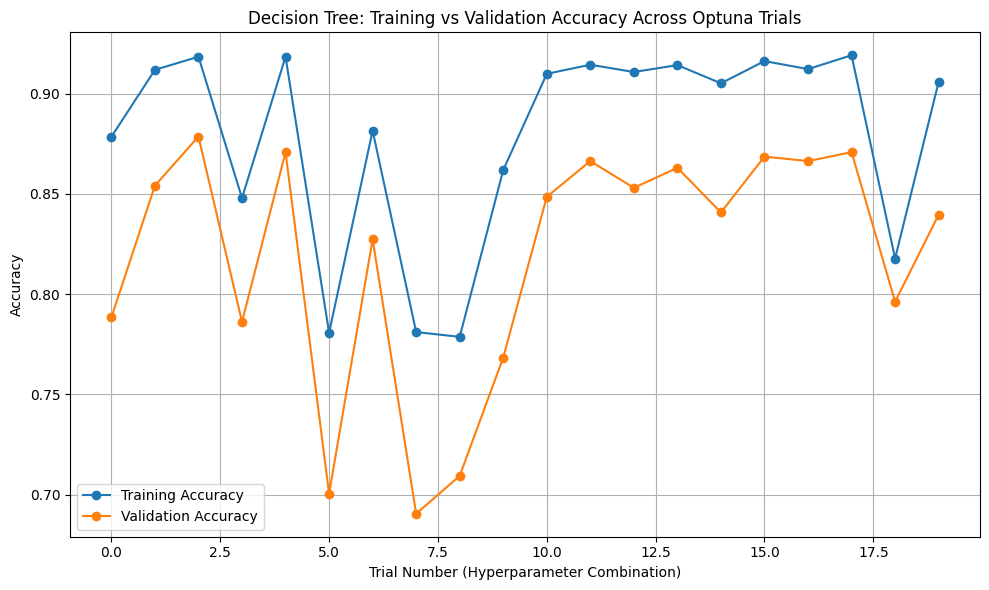


✅ GridSearchCV Best Parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best F1 Score from GridSearchCV: 0.923

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.91      0.94       861
           1       0.10      0.24      0.14        37

    accuracy                           0.88       898
   macro avg       0.53      0.58      0.54       898
weighted avg       0.93      0.88      0.90       898

Accuracy: 0.880
Precision: 0.533
Recall: 0.575
F1: 0.539
Roc_auc: 0.586


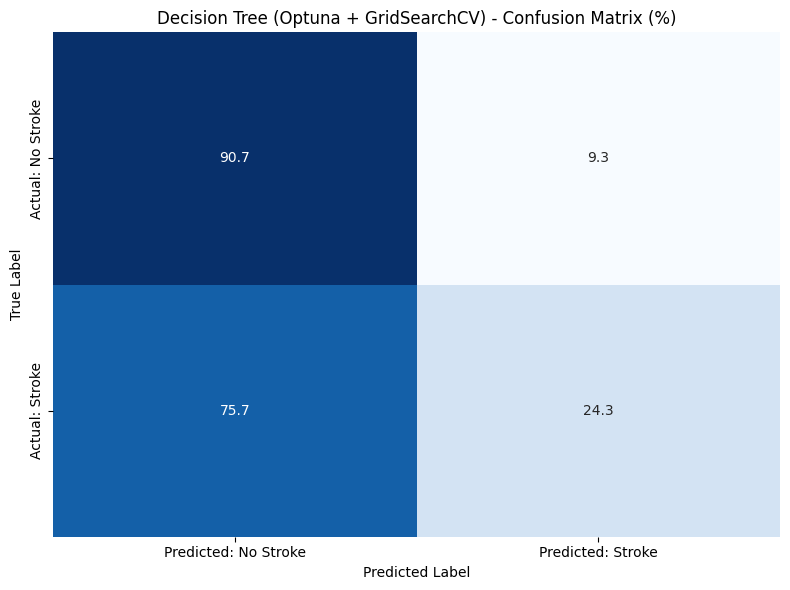

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import optuna
import seaborn as sns
import matplotlib.pyplot as plt

# === Step 1: Feature selection function ===
def select_features(X_train, y_train, X_test, method='mutual', k=10):
    selector = SelectKBest(score_func=mutual_info_classif if method == 'mutual' else f_classif, k=k)
    X_train_sel = selector.fit_transform(X_train, y_train)
    X_test_sel = selector.transform(X_test)
    return X_train_sel, X_test_sel, selector

# === Step 2: Optuna objective function with accuracy tracking ===
train_accuracies_dt = []
val_accuracies_dt = []

def optimize_dt(trial):
    k = trial.suggest_int('k', 5, min(15, X_train_resampled.shape[1]))
    max_depth = trial.suggest_int('max_depth', 3, 15)
    method = trial.suggest_categorical('method', ['kbest', 'mutual'])

    X_train_sel, X_test_sel, _ = select_features(X_train_resampled, y_train_resampled, X_test, method=method, k=k)
    model = DecisionTreeClassifier(max_depth=max_depth, class_weight='balanced')

    train_acc = cross_val_score(model, X_train_sel, y_train_resampled, cv=5, scoring='accuracy').mean()
    model.fit(X_train_sel, y_train_resampled)
    val_acc = accuracy_score(y_test, model.predict(X_test_sel))

    train_accuracies_dt.append(train_acc)
    val_accuracies_dt.append(val_acc)

    return val_acc

# === Step 3: Run Optuna optimization ===
study_dt = optuna.create_study(direction='maximize')
study_dt.optimize(optimize_dt, n_trials=20)

# === Plot Accuracy vs Trials ===
plt.figure(figsize=(10, 6))
plt.plot(range(len(train_accuracies_dt)), train_accuracies_dt, label="Training Accuracy", marker='o')
plt.plot(range(len(val_accuracies_dt)), val_accuracies_dt, label="Validation Accuracy", marker='o')
plt.xlabel("Trial Number (Hyperparameter Combination)")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Training vs Validation Accuracy Across Optuna Trials")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Step 4: Use best parameters from Optuna ===
best_k = study_dt.best_params['k']
best_depth = study_dt.best_params['max_depth']
best_method = study_dt.best_params['method']
X_train_dt, X_test_dt, selector_dt = select_features(X_train_resampled, y_train_resampled, X_test, method=best_method, k=best_k)

# === Step 5: GridSearchCV on Decision Tree ===
param_grid = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5]
}

grid_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(class_weight='balanced'),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_dt.fit(X_train_dt, y_train_resampled)
best_model = grid_dt.best_estimator_

print("\n✅ GridSearchCV Best Parameters:", grid_dt.best_params_)
print(f"Best F1 Score from GridSearchCV: {grid_dt.best_score_:.3f}")

# === Step 6: Train and evaluate ===
best_model.fit(X_train_dt, y_train_resampled)
y_pred = best_model.predict(X_test_dt)
y_prob = best_model.predict_proba(X_test_dt)[:, 1]

# === Step 7: Evaluation metrics ===
print("\nClassification Report:\n", classification_report(y_test, y_pred))


results['Decision Tree'] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, average='macro'),
    'recall': recall_score(y_test, y_pred, average='macro'),
    'f1': f1_score(y_test, y_pred, average='macro'),
    'roc_auc': roc_auc_score(y_test, y_prob)
}

for m, v in results['Decision Tree'].items():
    print(f"{m.capitalize()}: {v:.3f}")

# === Step 8: Confusion Matrix visualization ===
cm = confusion_matrix(y_test, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(8, 6))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap="Blues", cbar=False,
            xticklabels=['Predicted: No Stroke', 'Predicted: Stroke'],
            yticklabels=['Actual: No Stroke', 'Actual: Stroke'])

plt.title('Decision Tree (Optuna + GridSearchCV) - Confusion Matrix (%)')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


#Compare Classifier Performance


📊 Classifier Performance Summary:

               accuracy  precision  recall     f1  roc_auc
Naive Bayes       0.919      0.552   0.570  0.559    0.745
SVM               0.772      0.544   0.700  0.525    0.768
KNN               0.773      0.544   0.700  0.526    0.694
Decision Tree     0.880      0.533   0.575  0.539    0.586


<Figure size 1400x700 with 0 Axes>

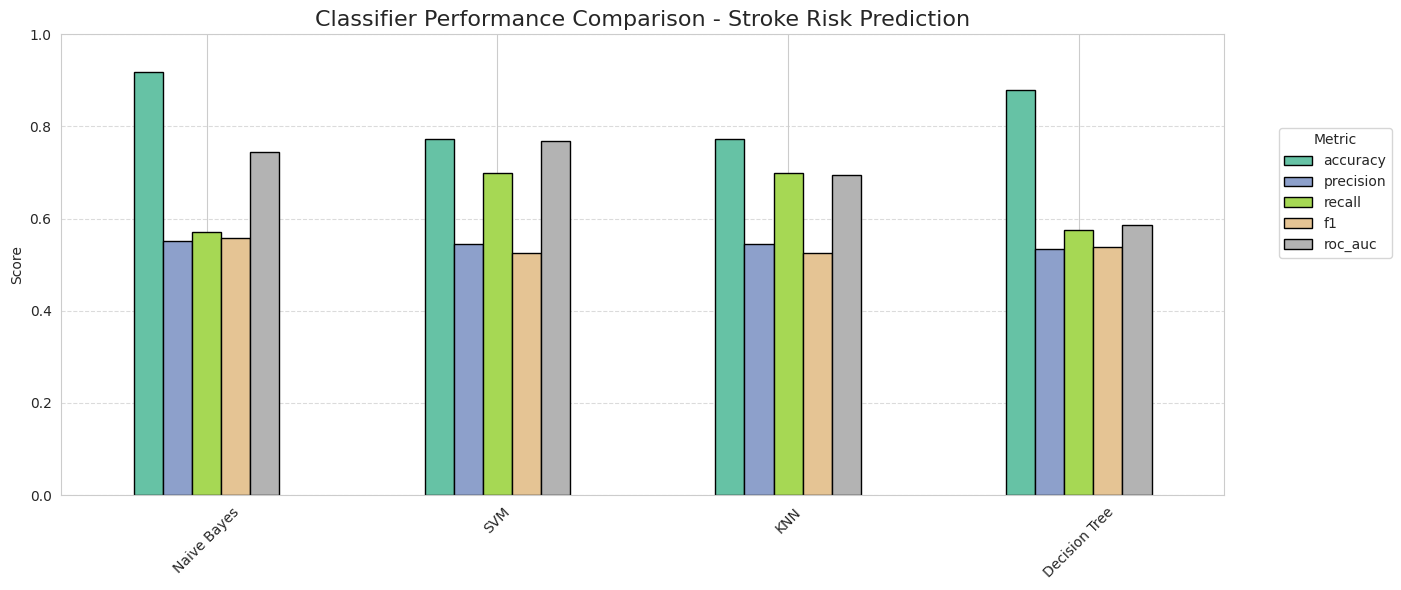

In [ ]:



# === Convert to DataFrame ===
results_df = pd.DataFrame(results).T.round(3)

# === Display the metrics table ===
print("\n📊 Classifier Performance Summary:\n")
print(results_df)

# === Plot grouped bar chart ===
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")
results_df.plot(kind='bar', figsize=(14, 6), colormap='Set2', edgecolor='black')

plt.title("Classifier Performance Comparison - Stroke Risk Prediction", fontsize=16)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(title='Metric', loc='lower right', bbox_to_anchor=(1.15, 0.5))
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


#Hierarchical Clustering with Dendrogram

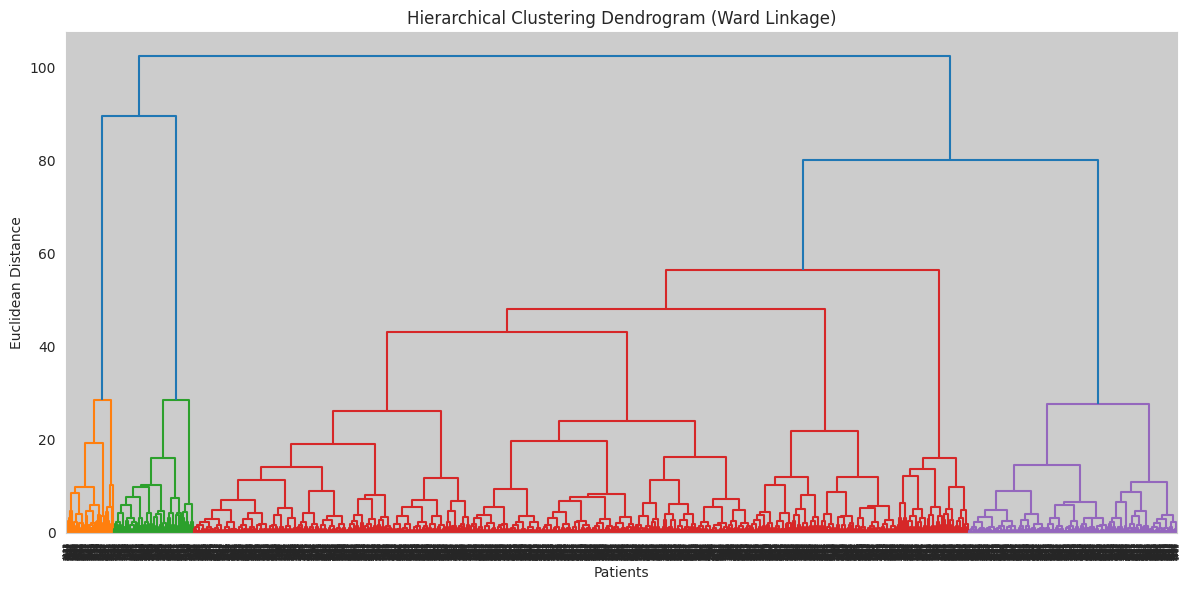

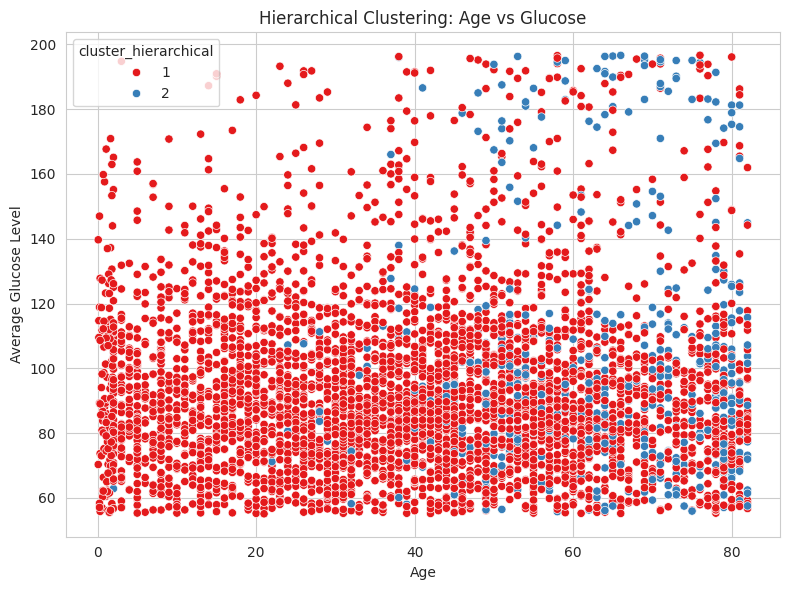

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Select features to cluster on (you can adjust these)
cluster_features = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease']

# Standardize features
scaler = StandardScaler()
X_cluster = scaler.fit_transform(df[cluster_features])

# Apply hierarchical clustering (Ward’s method = minimizes variance)
linked = linkage(X_cluster, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=False)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Patients')
plt.ylabel('Euclidean Distance')
plt.tight_layout()
plt.show()

# Form flat clusters (e.g., 2 clusters)
cluster_labels = fcluster(linked, t=2, criterion='maxclust')

# Attach to original data
df['cluster_hierarchical'] = cluster_labels

# Visualize clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='age', y='avg_glucose_level', hue='cluster_hierarchical', palette='Set1')
plt.title('Hierarchical Clustering: Age vs Glucose')
plt.xlabel('Age')
plt.ylabel('Average Glucose Level')
plt.tight_layout()
plt.show()


#Dendrogram for Hierarchical Clustering

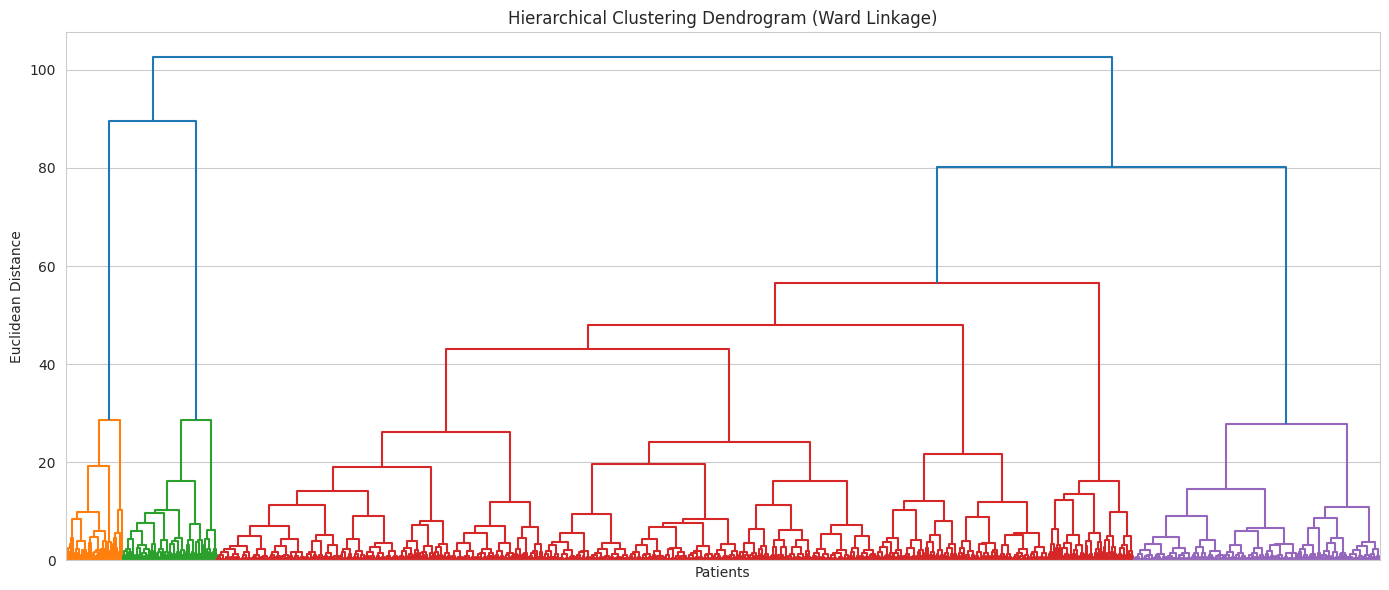

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

# Optional: select relevant features for clustering
features_for_clustering = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease']

# Step 1: Standardize the data
scaler = StandardScaler()
X_cluster = scaler.fit_transform(df[features_for_clustering])

# Step 2: Compute linkage matrix using Ward method
linked = linkage(X_cluster, method='ward')

# Step 3: Plot dendrogram
plt.figure(figsize=(14, 6))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=False,
           no_labels=True)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Patients')
plt.ylabel('Euclidean Distance')
plt.tight_layout()
plt.show()


#K-Means Clustering for Patient Grouping
#Use clustering results to gain insights into the patterns of patients at risk for strokes

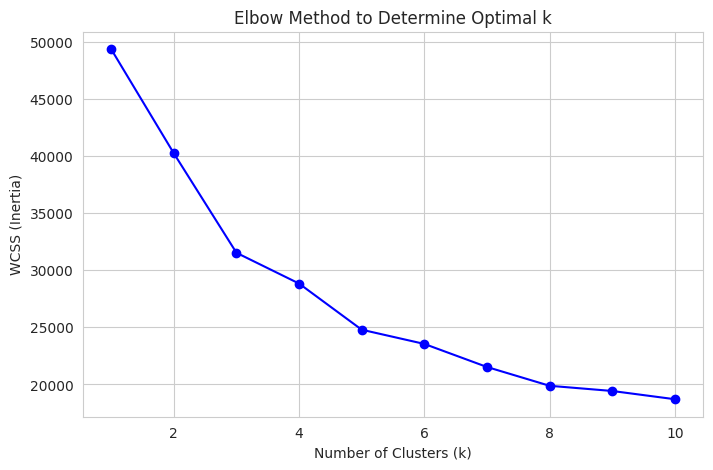

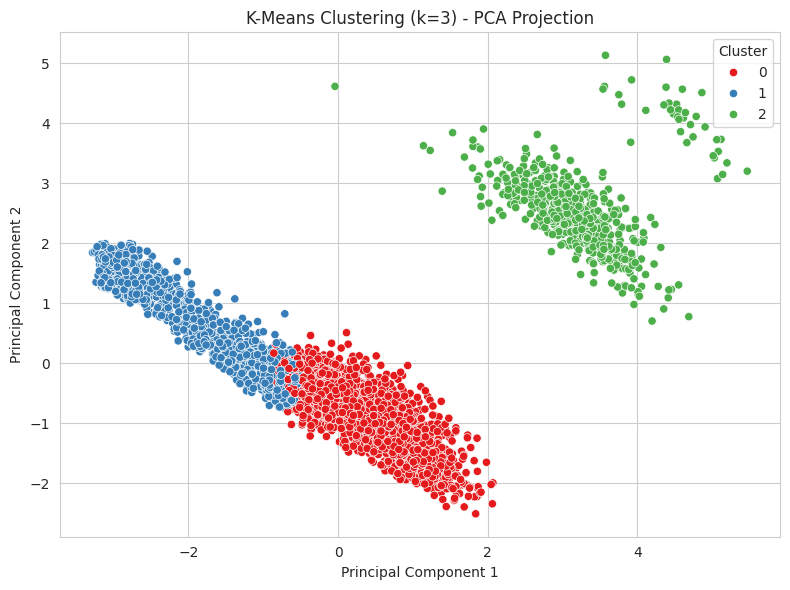

Silhouette Score for k=3: 0.236


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# === K-Means Clustering for Patient Segmentation ===

# Step 1: Prepare and scale features (excluding target 'stroke')
X_kmeans = df.drop(columns=['stroke']) if 'stroke' in df.columns else df.copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_kmeans)

# Step 2: Reduce dimensionality with PCA for visualization (optional)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 3: Use Elbow Method to identify optimal number of clusters
wcss = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method to Determine Optimal k')
plt.show()

# Step 4: Apply K-Means clustering with chosen k (e.g., k = 3)
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(X_scaled)

# Step 5: Visualize clusters in PCA-reduced 2D space
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = cluster_labels

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='Set1')
plt.title(f"K-Means Clustering (k={k_optimal}) - PCA Projection")
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

# Step 6 (Optional): Evaluate clustering quality with silhouette score
score = silhouette_score(X_scaled, cluster_labels)
print(f"Silhouette Score for k={k_optimal}: {score:.3f}")


# Compare clusters with the predicted labels from classifiers (e.g., comparinghigh-risk groups identified by classifiers vs. clustering).


Cluster vs. Predicted Stroke:
Predicted_Stroke    0   1
Cluster                  
0                 581  87
1                 228   2


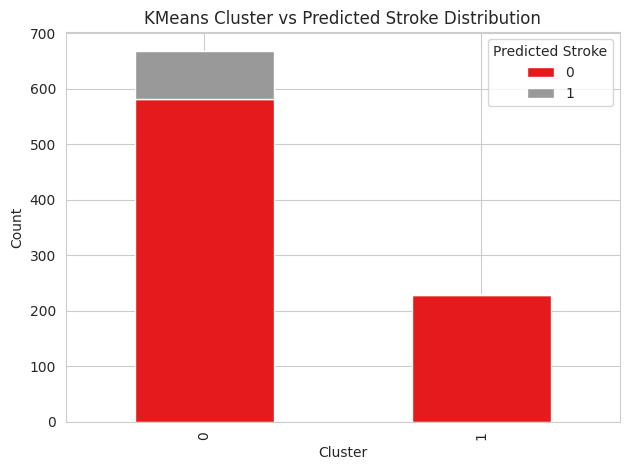

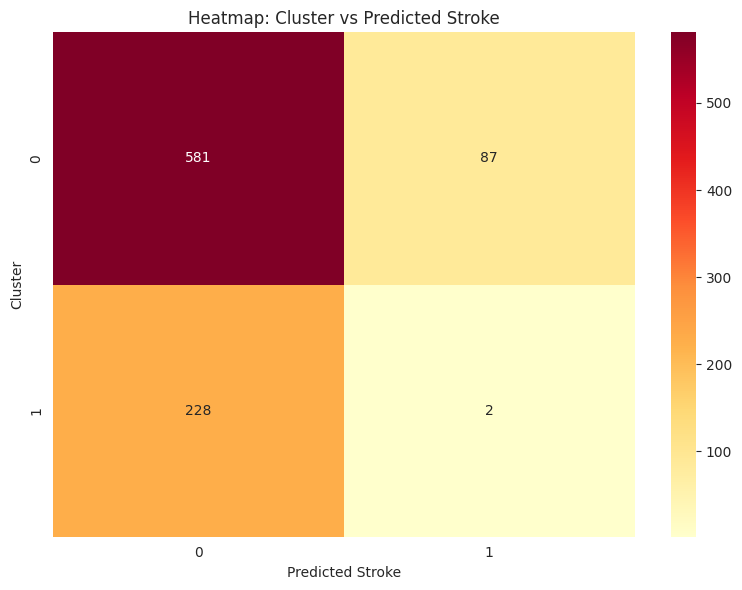

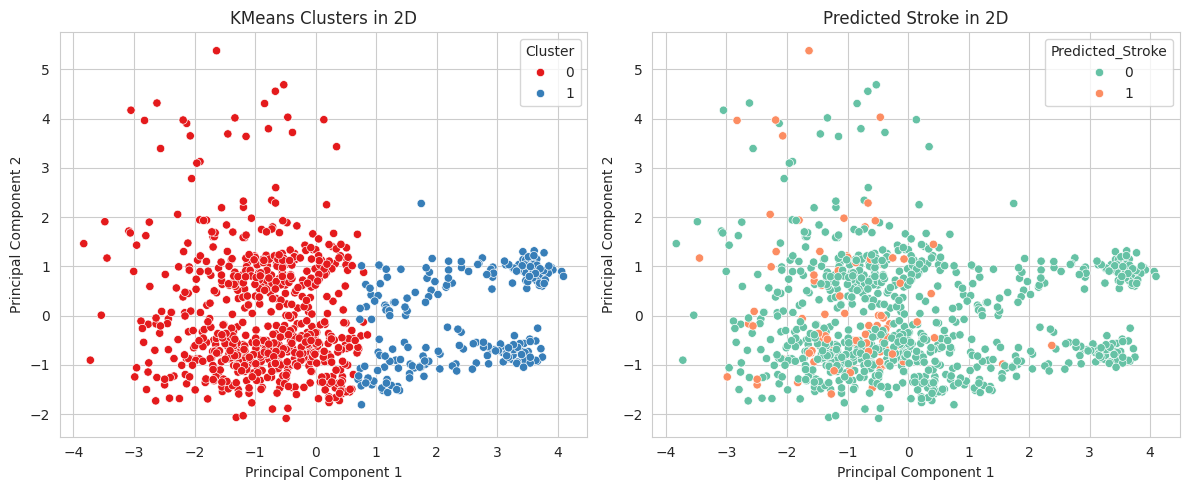

<Figure size 1000x600 with 0 Axes>

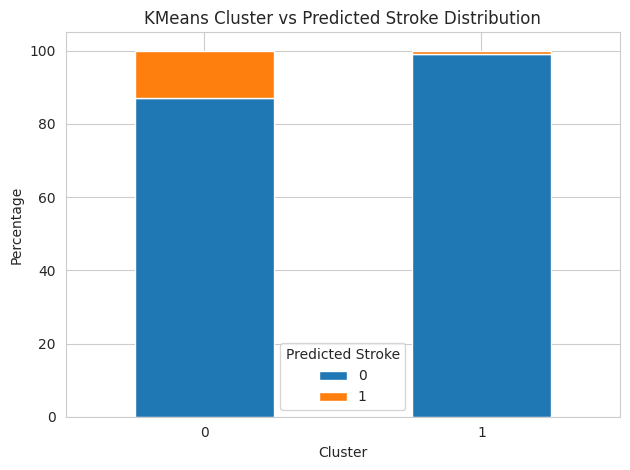

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd

# Step 1: Scale X_train and X_test using the same scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)  # resampled train set
X_test_scaled = scaler.transform(X_test)  # test set

# Step 2: Train K-Means on X_test
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X_test_scaled)

# Step 3: Use predicted labels from classifier (e.g., SVM or NB)
# Make sure you already have y_pred ready (e.g., from `model.predict(X_test_sel)`)

# Step 4: Compare clustering vs. classifier
compare_df = pd.DataFrame({
    'Cluster': cluster_labels,
    'Predicted_Stroke': y_pred
})

# Step 5: Crosstab for comparison
comparison = pd.crosstab(compare_df['Cluster'], compare_df['Predicted_Stroke'])
print("\nCluster vs. Predicted Stroke:")
print(comparison)


comparison.plot(kind='bar', stacked=True, colormap='Set1')
plt.title("KMeans Cluster vs Predicted Stroke Distribution")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.legend(title="Predicted Stroke")
plt.tight_layout()
plt.show()



# Step 6: Create Heatmap of Cluster vs Predicted Stroke
plt.figure(figsize=(8, 6))
sns.heatmap(comparison, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Heatmap: Cluster vs Predicted Stroke')
plt.xlabel('Predicted Stroke')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

# Step 7: Visualize Cluster vs Classifier Labels in 2D
# Use PCA to reduce dimensions for visualization
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test_scaled)

# Create DataFrame for plotting
plot_df = pd.DataFrame({
    'PC1': X_test_pca[:, 0],
    'PC2': X_test_pca[:, 1],
    'Cluster': cluster_labels,
    'Predicted_Stroke': y_pred
})

# Plot clusters
plt.figure(figsize=(12, 5))

# Plot 1: Clusters
plt.subplot(1, 2, 1)
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='Cluster', palette='Set1')
plt.title('KMeans Clusters in 2D')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Plot 2: Predicted Stroke
plt.subplot(1, 2, 2)
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='Predicted_Stroke', palette='Set2')
plt.title('Predicted Stroke in 2D')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.tight_layout()
plt.show()

# Step 8: KMeans Cluster vs Predicted Stroke Distribution
plt.figure(figsize=(10, 6))
cluster_stroke_dist = pd.crosstab(compare_df['Cluster'], compare_df['Predicted_Stroke'], normalize='index') * 100
cluster_stroke_dist.plot(kind='bar', stacked=True)
plt.title('KMeans Cluster vs Predicted Stroke Distribution')
plt.xlabel('Cluster')
plt.ylabel('Percentage')
plt.legend(title='Predicted Stroke')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
